# Tutorial 08A — Custom Object Detection using YOLOv8

## Objective

This notebook implements **Tutorial 08A: Custom Object Detection** using PyTorch-based YOLOv8.

The tutorial uses the custom labeled dataset created in Roboflow.

Classes:

- Ororon
- furina

The notebook covers:

- Loading the custom YOLO dataset
- Checking dataset structure
- Visualizing labeled bounding boxes
- Training a YOLOv8 object detection model
- Testing the model on validation and test images
- Visualizing predictions
- Comparing different training settings

Expected folder structure:

```text
Tutorial_08/
├── tutorial_08A_custom_object_detection_fixed.ipynb
├── dataset/
│   ├── train/
│   │   ├── images/
│   │   └── labels/
│   ├── valid/
│   │   ├── images/
│   │   └── labels/
│   ├── test/
│   │   ├── images/
│   │   └── labels/
│   └── data.yaml
└── images/
```

## Important Fix Included

This version includes fixes for the error:

```text
RuntimeError: Pin memory thread exited unexpectedly
AttributeError: 'numpy.ufunc' object has no attribute '__module__'
```

The fixes are:

- Force NumPy 1.26.4 if NumPy 2.x is installed
- Use `workers=0` in all YOLO training calls
- Disable Ultralytics DataLoader pin memory where possible


## 0. One-Time NumPy Fix

Run this cell first.

If it installs NumPy 1.26.4, **restart the kernel** and then run the notebook again from the start.

If it says NumPy is already compatible, continue normally.


In [1]:
import sys
import subprocess

try:
    import numpy as np
    np_major = int(np.__version__.split(".")[0])

    print("Current NumPy version:", np.__version__)

    if np_major >= 2:
        print("NumPy 2.x detected. Installing NumPy 1.26.4 for compatibility...")
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "numpy==1.26.4",
            "--force-reinstall"
        ])

        raise SystemExit(
            "NumPy was changed to 1.26.4. Restart the kernel, then run all cells again."
        )
    else:
        print("NumPy version is compatible. Continue running the notebook.")

except Exception as e:
    print("NumPy compatibility check error:", e)
    print("If training crashes, run: pip install numpy==1.26.4 --force-reinstall")


Current NumPy version: 1.26.4
NumPy version is compatible. Continue running the notebook.


## 1. Install and Import Required Libraries

In [2]:
import os
import sys
import random
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import torch

# Install ultralytics if missing
try:
    import ultralytics
    from ultralytics import YOLO
    ULTRALYTICS_AVAILABLE = True
except ImportError:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "ultralytics"])
        import ultralytics
        from ultralytics import YOLO
        ULTRALYTICS_AVAILABLE = True
    except Exception as e:
        print("Ultralytics could not be installed.")
        print("Reason:", e)
        ULTRALYTICS_AVAILABLE = False

# Disable Ultralytics pin memory where possible.
# This helps avoid "pin memory thread exited unexpectedly" on some Windows + NumPy setups.
if ULTRALYTICS_AVAILABLE:
    try:
        import ultralytics.data.build as ultralytics_data_build
        ultralytics_data_build.PIN_MEMORY = False
        print("Ultralytics PIN_MEMORY disabled.")
    except Exception as e:
        print("Could not modify Ultralytics PIN_MEMORY setting:", e)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Ultralytics available:", ULTRALYTICS_AVAILABLE)

if ULTRALYTICS_AVAILABLE:
    print("Ultralytics version:", ultralytics.__version__)

os.makedirs("images", exist_ok=True)


Ultralytics PIN_MEMORY disabled.
PyTorch version: 2.5.1+cu121
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Ultralytics available: True
Ultralytics version: 8.4.51


## 2. Dataset Path

Place the Roboflow-exported YOLOv8 dataset inside a folder named `dataset`.

The notebook expects:

```text
dataset/data.yaml
dataset/train/images
dataset/train/labels
dataset/valid/images
dataset/valid/labels
dataset/test/images
dataset/test/labels
```


In [3]:
DATASET_DIR = Path("dataset")
ORIGINAL_DATA_YAML = DATASET_DIR / "data.yaml"

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        "Dataset folder not found. Put the Roboflow YOLOv8 export in a folder named 'dataset'."
    )

if not ORIGINAL_DATA_YAML.exists():
    raise FileNotFoundError(
        "data.yaml not found. Expected path: dataset/data.yaml"
    )

print("Dataset folder found:", DATASET_DIR)
print("Original data.yaml found:", ORIGINAL_DATA_YAML)


Dataset folder found: dataset
Original data.yaml found: dataset\data.yaml


## 3. Read Dataset Information and Create Fixed YAML

Some Roboflow exports use paths like:

```text
../train/images
```

To avoid path issues, this notebook creates a fixed YAML file:

```text
dataset/data_fixed.yaml
```

with paths relative to the `dataset` folder.


In [4]:
import yaml

with open(ORIGINAL_DATA_YAML, "r", encoding="utf-8") as f:
    data_yaml_original = yaml.safe_load(f)

print("Original data.yaml:")
print(data_yaml_original)

class_names = data_yaml_original["names"]
num_classes = data_yaml_original["nc"]

# Create a fixed dataset YAML that works with this notebook structure.
fixed_yaml = {
    "path": str(DATASET_DIR.resolve()),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": num_classes,
    "names": class_names
}

FIXED_DATA_YAML = DATASET_DIR / "data_fixed.yaml"

with open(FIXED_DATA_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(fixed_yaml, f, sort_keys=False)

print("\nFixed data.yaml saved at:", FIXED_DATA_YAML)
print(fixed_yaml)

print("\nNumber of classes:", num_classes)
print("Class names:", class_names)


Original data.yaml:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 2, 'names': ['Ororon', 'furina'], 'roboflow': {'workspace': 'bakas-workspace-5yl3w', 'project': 'tutorial-8', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/bakas-workspace-5yl3w/tutorial-8/dataset/1'}}

Fixed data.yaml saved at: dataset\data_fixed.yaml
{'path': 'C:\\Users\\mumer\\Downloads\\T8\\dataset', 'train': 'train/images', 'val': 'valid/images', 'test': 'test/images', 'nc': 2, 'names': ['Ororon', 'furina']}

Number of classes: 2
Class names: ['Ororon', 'furina']


## 4. Count Images and Labels

In [5]:
def count_files(folder, extensions):
    folder = Path(folder)
    count = 0

    for ext in extensions:
        count += len(list(folder.glob(f"*{ext}")))

    return count


splits = ["train", "valid", "test"]
summary_rows = []

for split in splits:
    image_dir = DATASET_DIR / split / "images"
    label_dir = DATASET_DIR / split / "labels"

    image_count = count_files(image_dir, [".jpg", ".jpeg", ".png"])
    label_count = count_files(label_dir, [".txt"])

    summary_rows.append({
        "Split": split,
        "Images": image_count,
        "Labels": label_count
    })

dataset_summary_df = pd.DataFrame(summary_rows)
dataset_summary_df


,Split,Images,Labels
0,train,102,102
1,valid,29,29
2,test,14,14


## 5. Visualize Labeled Bounding Boxes

YOLO annotation format:

```text
class_id x_center y_center width height
```

The coordinates are normalized between 0 and 1.


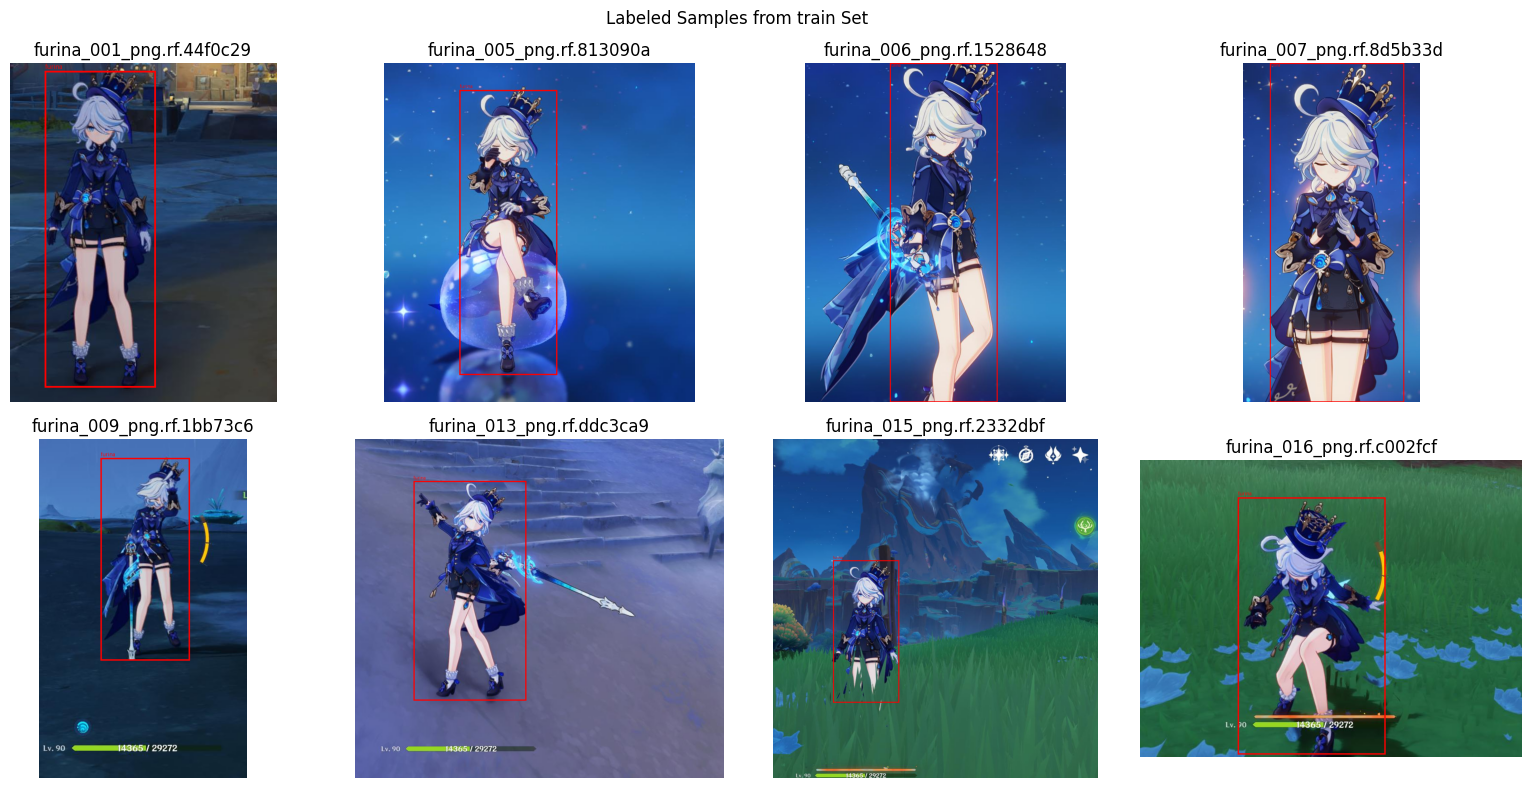

In [6]:
def read_yolo_labels(label_path):
    boxes = []

    if not Path(label_path).exists():
        return boxes

    with open(label_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()

        if len(parts) != 5:
            continue

        class_id = int(float(parts[0]))
        x_center = float(parts[1])
        y_center = float(parts[2])
        width = float(parts[3])
        height = float(parts[4])

        boxes.append({
            "class_id": class_id,
            "x_center": x_center,
            "y_center": y_center,
            "width": width,
            "height": height
        })

    return boxes


def draw_yolo_boxes(image_path, label_path, class_names):
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    img_w, img_h = image.size
    boxes = read_yolo_labels(label_path)

    for box in boxes:
        class_id = box["class_id"]

        x_center = box["x_center"] * img_w
        y_center = box["y_center"] * img_h
        width = box["width"] * img_w
        height = box["height"] * img_h

        x1 = x_center - width / 2
        y1 = y_center - height / 2
        x2 = x_center + width / 2
        y2 = y_center + height / 2

        label = class_names[class_id]

        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
        draw.text((x1, max(0, y1 - 14)), label, fill="red")

    return image


def show_labeled_samples(split="train", n_images=8):
    image_dir = DATASET_DIR / split / "images"
    label_dir = DATASET_DIR / split / "labels"

    image_paths = sorted(
        list(image_dir.glob("*.jpg")) +
        list(image_dir.glob("*.png")) +
        list(image_dir.glob("*.jpeg"))
    )

    selected_paths = image_paths[:n_images]

    plt.figure(figsize=(16, 8))

    for i, image_path in enumerate(selected_paths):
        label_path = label_dir / (image_path.stem + ".txt")
        labeled_image = draw_yolo_boxes(image_path, label_path, class_names)

        plt.subplot(2, 4, i + 1)
        plt.imshow(labeled_image)
        plt.title(image_path.name[:25])
        plt.axis("off")

    plt.suptitle(f"Labeled Samples from {split} Set")
    plt.tight_layout()
    plt.savefig(f"images/tutorial_08A_labeled_samples_{split}.png", dpi=300, bbox_inches="tight")
    plt.show()


show_labeled_samples(split="train", n_images=8)


## 6. Train YOLOv8n Model

A small YOLOv8 model is used for custom object detection.

The base model is:

```text
yolov8n.pt
```

This is the nano version, which is lightweight and suitable for a small dataset.


In [7]:
if not ULTRALYTICS_AVAILABLE:
    raise ImportError("Ultralytics is not available. Please install it using: pip install ultralytics")

BASE_MODEL = "yolov8n.pt"

model = YOLO(BASE_MODEL)

print("Base model loaded:", BASE_MODEL)


Base model loaded: yolov8n.pt


## 7. Training Settings

For a small course project dataset, start with a small number of epochs.

This cell includes:

```python
workers=0
```

to avoid Windows multiprocessing/pin-memory crashes.


In [8]:
EPOCHS = 25
IMAGE_SIZE = 640
BATCH_SIZE = 8

results = model.train(
    data=str(FIXED_DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    seed=SEED,
    workers=0,
    project="runs/tutorial_08A",
    name="yolov8n_custom",
    exist_ok=True
)


Ultralytics 8.4.51  Python-3.10.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset\data_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_custom, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

## 8. Validate the Trained YOLOv8n Model

In [11]:
from pathlib import Path

# Find trained YOLOv8n weights automatically
possible_weights = list(Path(".").rglob("yolov8n_custom/weights/best.pt"))

if len(possible_weights) == 0:
    possible_weights = list(Path(".").rglob("yolov8n_custom/weights/last.pt"))

print("Found weights:")
for p in possible_weights:
    print(p)

if len(possible_weights) == 0:
    raise FileNotFoundError(
        "No YOLOv8n trained weights found. The training cell may not have completed successfully."
    )

trained_model_path = possible_weights[0]
print("Using trained model:", trained_model_path)

trained_model = YOLO(str(trained_model_path))

metrics = trained_model.val(
    data=str(FIXED_DATA_YAML),
    split="val",
    imgsz=IMAGE_SIZE,
    workers=0,
    project="runs/tutorial_08A",
    name="validation_results",
    exist_ok=True
)

print(metrics)

Found weights:
runs\detect\runs\tutorial_08A\yolov8n_custom\weights\best.pt
Using trained model: runs\detect\runs\tutorial_08A\yolov8n_custom\weights\best.pt
Ultralytics 8.4.51  Python-3.10.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 548.4364.2 MB/s, size: 56.5 KB)
val: Scanning C:\Users\mumer\Downloads\T8\dataset\valid\labels.cache... 29 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 29/29  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.6it/s 0.8s1.5s
                   all         29         29      0.995      0.898      0.976       0.71
                Ororon         15         15      0.991      0.867      0.961      0.749
                furina         14         14      0.999      0.929       0.99      0.671
Speed: 1.4ms preprocess, 10.0ms inference

## 9. Test the Trained YOLOv8n Model

In [12]:
test_metrics = trained_model.val(
    data=str(FIXED_DATA_YAML),
    split="test",
    imgsz=IMAGE_SIZE,
    workers=0,
    project="runs/tutorial_08A",
    name="test_results",
    exist_ok=True
)

print(test_metrics)


Ultralytics 8.4.51  Python-3.10.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 0.30.2 ms, read: 10.46.2 MB/s, size: 69.3 KB)
val: Scanning C:\Users\mumer\Downloads\T8\dataset\test\labels... 14 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 14/14 653.2it/s 0.0s
val: New cache created: C:\Users\mumer\Downloads\T8\dataset\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.9it/s 0.5s
                   all         14         14      0.937      0.991      0.995       0.67
                Ororon          8          8          1      0.982      0.995      0.693
                furina          6          6      0.874          1      0.995      0.648
Speed: 4.4ms preprocess, 20.6ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to C:\Users\mumer\Downloads\T8\runs\detect\runs\tutorial_08A\test_results
ultralytics.utils.metrics.DetMetric

## 10. Run Prediction on Test Images

Predictions are saved automatically in the `runs/tutorial_08A/test_predictions` folder.


In [17]:
test_images_dir = DATASET_DIR / "test" / "images"

prediction_results = trained_model.predict(
    source=str(test_images_dir),
    imgsz=IMAGE_SIZE,
    conf=0.25,
    save=True,
    project="images",
    name="tutorial_08A_predictions",
    exist_ok=True
)

print("Prediction completed.")
print("Predictions saved to: images/tutorial_08A_predictions")


image 1/14 c:\Users\mumer\Downloads\T8\dataset\test\images\furina_011_png.rf.a7f7d3c671a4189fe711a2edb0a3e8f3.jpg: 416x640 1 furina, 19.7ms
image 2/14 c:\Users\mumer\Downloads\T8\dataset\test\images\furina_019_png.rf.aad4870620e01b77b03fad122becd185.jpg: 448x640 1 furina, 20.9ms
image 3/14 c:\Users\mumer\Downloads\T8\dataset\test\images\furina_039_png.rf.dcc066d6578f61fe107fa98caf1a6036.jpg: 640x512 1 furina, 82.8ms
image 4/14 c:\Users\mumer\Downloads\T8\dataset\test\images\furina_049_png.rf.aee99aae00b0747dc80c69108a45d458.jpg: 576x640 1 furina, 40.9ms
image 5/14 c:\Users\mumer\Downloads\T8\dataset\test\images\furina_071_png.rf.3d5df2fe212c44c944eca7b53a412c92.jpg: 480x640 1 furina, 25.1ms
image 6/14 c:\Users\mumer\Downloads\T8\dataset\test\images\furina_075_png.rf.5a18fed7639bdda9f3bf0d5fdf498202.jpg: 384x640 1 furina, 35.1ms
image 7/14 c:\Users\mumer\Downloads\T8\dataset\test\images\ororon_004_png.rf.0deb371465dafa97a7a6bb135dca8565.jpg: 480x640 1 Ororon, 18.0ms
image 8/14 c:\Users

## 11. Visualize Prediction Results

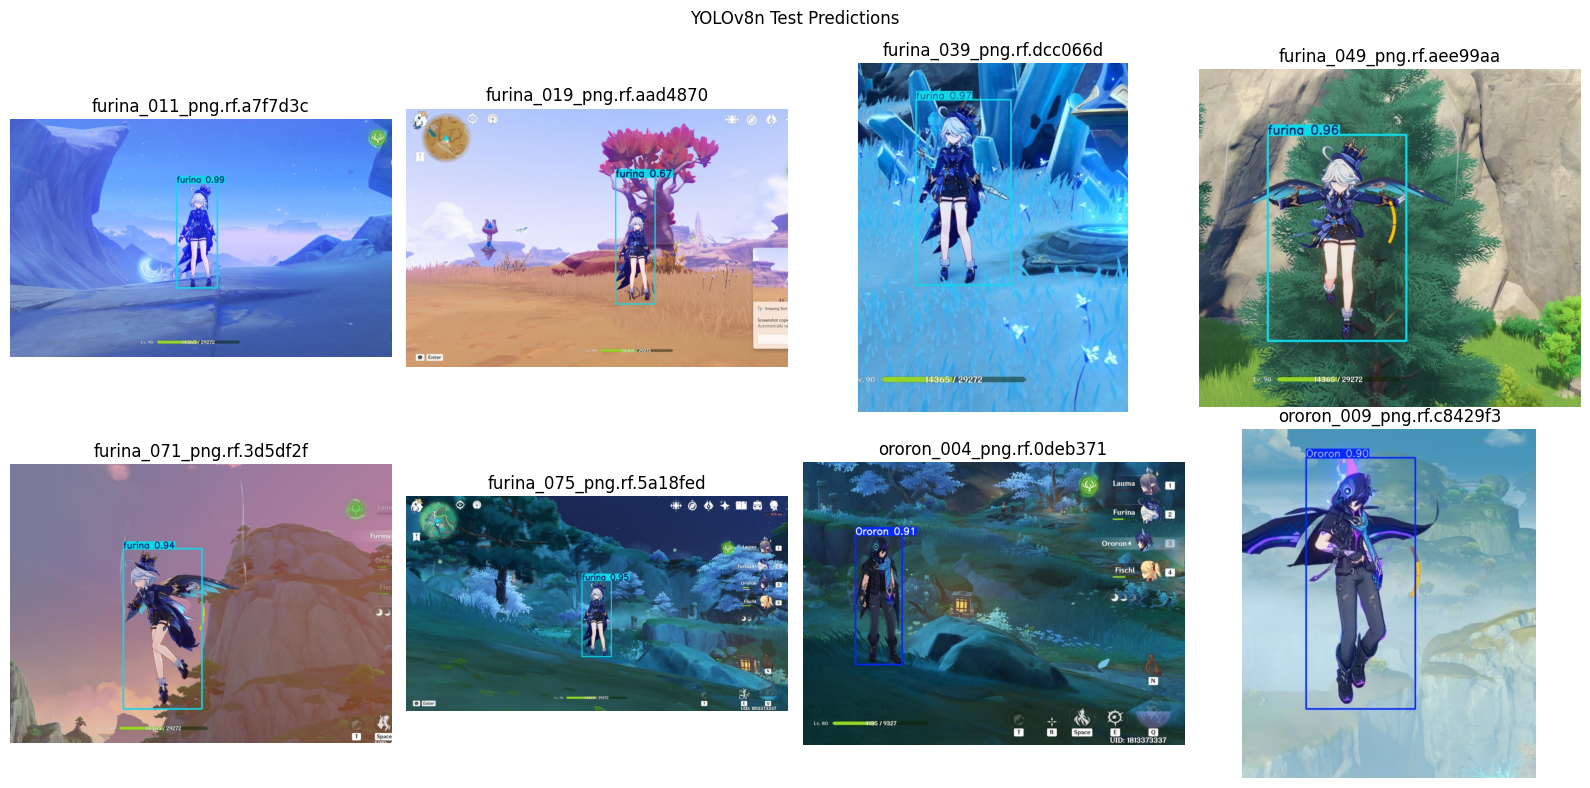

In [19]:
show_prediction_images(
    prediction_folder="runs/detect/images/tutorial_08A_predictions",
    filename="images/tutorial_08A_yolov8n_test_predictions.png",
    n_images=8
)


# Task — Change Model/Training Settings

The tutorial asks to test the developed data on the model and change the model/layers.

For YOLOv8, a practical way to test architecture variation is to compare two model sizes:

- YOLOv8n: smaller model
- YOLOv8s: slightly larger model

This compares a lighter and deeper/wider object detection architecture.


## 12. Train YOLOv8s Model

In [15]:
BASE_MODEL_2 = "yolov8s.pt"

model_s = YOLO(BASE_MODEL_2)

results_s = model_s.train(
    data=str(FIXED_DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    seed=SEED,
    workers=0,
    project="runs/tutorial_08A",
    name="yolov8s_custom",
    exist_ok=True
)


Ultralytics 8.4.51  Python-3.10.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset\data_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_custom, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

## 13. Validate YOLOv8s Model

In [20]:
from pathlib import Path

# Find trained YOLOv8s weights automatically
possible_weights_s = list(Path(".").rglob("yolov8s_custom/weights/best.pt"))

if len(possible_weights_s) == 0:
    possible_weights_s = list(Path(".").rglob("yolov8s_custom/weights/last.pt"))

print("Found YOLOv8s weights:")
for p in possible_weights_s:
    print(p)

if len(possible_weights_s) == 0:
    raise FileNotFoundError(
        "No YOLOv8s trained weights found. The YOLOv8s training cell may not have completed successfully."
    )

trained_model_s_path = possible_weights_s[0]
print("Using YOLOv8s trained model:", trained_model_s_path)

trained_model_s = YOLO(str(trained_model_s_path))

metrics_s = trained_model_s.val(
    data=str(FIXED_DATA_YAML),
    split="test",
    imgsz=IMAGE_SIZE,
    workers=0,
    project="runs/tutorial_08A",
    name="test_results_yolov8s",
    exist_ok=True
)

print(metrics_s)


Found YOLOv8s weights:
runs\detect\runs\tutorial_08A\yolov8s_custom\weights\best.pt
Using YOLOv8s trained model: runs\detect\runs\tutorial_08A\yolov8s_custom\weights\best.pt
Ultralytics 8.4.51  Python-3.10.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 728.5252.0 MB/s, size: 78.8 KB)
val: Scanning C:\Users\mumer\Downloads\T8\dataset\test\labels.cache... 14 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 14/14  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.9it/s 0.3s
                   all         14         14      0.954          1      0.995       0.66
                Ororon          8          8       0.99          1      0.995      0.622
                furina          6          6      0.918          1      0.995      0.697
Speed: 0.6ms preprocess, 7.4

## 14. Compare Learning Rates

The tutorial also asks to use different learning rates and visualize results.

Here, a second YOLOv8n model is trained with a different initial learning rate.


In [21]:
model_lr = YOLO(BASE_MODEL)

results_lr = model_lr.train(
    data=str(FIXED_DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    seed=SEED,
    lr0=0.005,
    workers=0,
    project="runs/tutorial_08A",
    name="yolov8n_lr_0_005",
    exist_ok=True
)


Ultralytics 8.4.51  Python-3.10.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset\data_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_lr_0_005, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

## 15. Validate Different Learning Rate Model

In [23]:
from pathlib import Path

# Find trained YOLOv8n learning-rate experiment weights automatically
possible_weights_lr = list(Path(".").rglob("yolov8n_lr_0_005/weights/best.pt"))

if len(possible_weights_lr) == 0:
    possible_weights_lr = list(Path(".").rglob("yolov8n_lr_0_005/weights/last.pt"))

print("Found YOLOv8n LR weights:")
for p in possible_weights_lr:
    print(p)

if len(possible_weights_lr) == 0:
    raise FileNotFoundError(
        "No YOLOv8n LR trained weights found. The learning-rate training cell may not have completed successfully."
    )

trained_model_lr_path = possible_weights_lr[0]
print("Using YOLOv8n LR trained model:", trained_model_lr_path)

trained_model_lr = YOLO(str(trained_model_lr_path))

metrics_lr = trained_model_lr.val(
    data=str(FIXED_DATA_YAML),
    split="test",
    imgsz=IMAGE_SIZE,
    workers=0,
    project="runs/tutorial_08A",
    name="test_results_yolov8n_lr_0_005",
    exist_ok=True
)

print(metrics_lr)

Found YOLOv8n LR weights:
runs\detect\runs\tutorial_08A\yolov8n_lr_0_005\weights\best.pt
Using YOLOv8n LR trained model: runs\detect\runs\tutorial_08A\yolov8n_lr_0_005\weights\best.pt
Ultralytics 8.4.51  Python-3.10.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 728.6284.8 MB/s, size: 78.8 KB)
val: Scanning C:\Users\mumer\Downloads\T8\dataset\test\labels.cache... 14 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 14/14  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.9it/s 0.3s
                   all         14         14       0.96      0.925      0.975      0.634
                Ororon          8          8          1       0.85      0.955      0.613
                furina          6          6      0.919          1      0.995      0.655
Speed: 0.6ms preproc

## 16. Compare Training Settings

After training, fill this table using the metrics printed above or the result images saved by YOLO.

Common YOLO metrics:

- Precision
- Recall
- mAP50
- mAP50-95


In [24]:
comparison_df = pd.DataFrame([
    {
        "Model": "YOLOv8n",
        "Epochs": EPOCHS,
        "Image Size": IMAGE_SIZE,
        "Batch Size": BATCH_SIZE,
        "Learning Rate": "default",
        "Notes": "baseline small model"
    },
    {
        "Model": "YOLOv8s",
        "Epochs": EPOCHS,
        "Image Size": IMAGE_SIZE,
        "Batch Size": BATCH_SIZE,
        "Learning Rate": "default",
        "Notes": "larger model"
    },
    {
        "Model": "YOLOv8n",
        "Epochs": EPOCHS,
        "Image Size": IMAGE_SIZE,
        "Batch Size": BATCH_SIZE,
        "Learning Rate": "0.005",
        "Notes": "different learning rate"
    }
])

comparison_df


,Model,Epochs,Image Size,Batch Size,Learning Rate,Notes
0,YOLOv8n,25,640,8,default,baseline small model
1,YOLOv8s,25,640,8,default,larger model
2,YOLOv8n,25,640,8,0.005,different learning rate


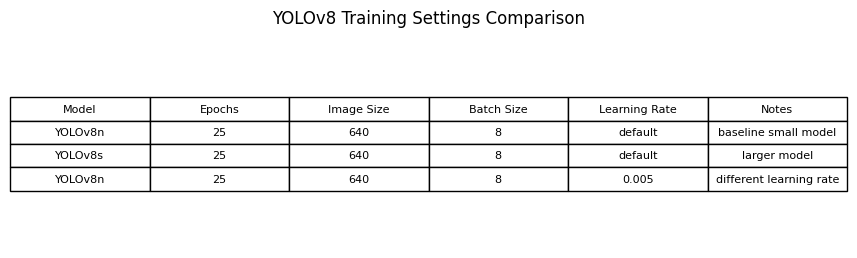

In [25]:
def save_dataframe_as_image(df, filename, title=None, fontsize=9):
    fig_width = max(8, len(df.columns) * 1.8)
    fig_height = max(2.5, len(df) * 0.5 + 1.2)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.4)

    if title:
        ax.set_title(title, fontsize=12, pad=12)

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


save_dataframe_as_image(
    comparison_df,
    "images/tutorial_08A_model_training_settings_table.png",
    title="YOLOv8 Training Settings Comparison",
    fontsize=8
)


# Final Observations

## Custom Dataset

The custom object detection dataset contains two classes: Ororon and furina.  
Each image was manually labeled with a bounding box around the character.

## YOLOv8 Object Detection

YOLOv8 was trained on the custom dataset to detect the characters.  
Unlike classification, object detection predicts both the class label and the bounding box location.

## Architecture Change

YOLOv8n and YOLOv8s were compared to test the effect of changing the model architecture.  
YOLOv8s is larger than YOLOv8n and has more capacity.

## Learning Rate Change

A second YOLOv8n model was trained with a different learning rate to observe how training settings affect detection performance.

## Key Learning

Object detection requires labeled bounding boxes.  
The output of the model is not just the class name, but also the object location in the image.
